**Installing & importing libraries**

In [ ]:
!pip install kaggle

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

**Data Loading Using Kaggle API**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!mkdir -p ~/.kaggle
!cp "/content/drive/MyDrive/Colab Notebooks/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle datasets download -d aaravsubedi/parikar-nepali-food --unzip

Dataset URL: https://www.kaggle.com/datasets/aaravsubedi/parikar-nepali-food
License(s): CC0-1.0
100% 2.01G/2.01G [00:23<00:00, 90.5MB/s]



## Data Loading and Data Analysis

In [16]:
from torchvision import datasets, transforms

In [34]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [71]:
data_dir = "/content/parikar"

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

## Basic Dataset Overview
Understand dataset structure:total images,number of classes,class names

In [70]:
print("Total images:", len(dataset))
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))

Total images: 15258
Classes: ['Burger', 'Chiya', 'Dalbhat', 'Friedrice', 'Jeri', 'Momo', 'Omelette', 'Pakoda', 'Panipuri', 'Pizza', 'Roti', 'Samosa', 'Selroti', 'Yomari', 'chatamari', 'chhoila', 'dhindo', 'gundruk', 'kheer', 'sekuwa']
Number of classes: 20


## Class names and Counts
Check number of images per class

In [21]:
from collections import Counter

In [35]:
def get_class_info(dataset):
    class_names = dataset.classes
    targets = [label for _, label in dataset.imgs]

    counts = Counter(targets)

    print(" Class Distribution:")
    for idx, count in counts.items():
        print(f"{class_names[idx]}: {count} images")

    return class_names, counts
class_names, class_counts = get_class_info(dataset)

 Class Distribution:
Burger: 1242 images
Chiya: 1261 images
Dalbhat: 1041 images
Friedrice: 926 images
Jeri: 1015 images
Momo: 1030 images
Omelette: 1214 images
Pakoda: 280 images
Panipuri: 1054 images
Pizza: 986 images
Roti: 994 images
Samosa: 1039 images
Selroti: 1407 images
Yomari: 679 images
chatamari: 178 images
chhoila: 150 images
dhindo: 135 images
gundruk: 107 images
kheer: 361 images
sekuwa: 159 images


## Visualize class distribution


In [36]:
import matplotlib.pyplot as plt

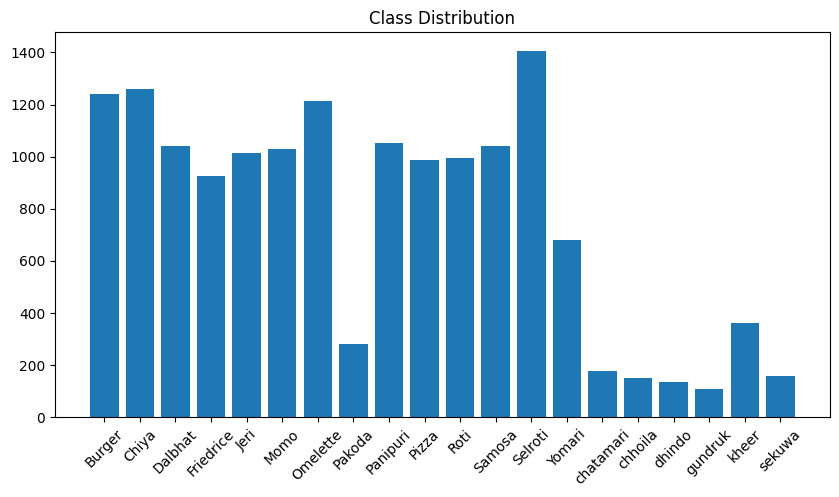

In [37]:
def plot_distribution(class_names, class_counts):
    values = [class_counts[i] for i in range(len(class_names))]

    plt.figure(figsize=(10,5))
    plt.bar(class_names, values)
    plt.xticks(rotation=45)
    plt.title("Class Distribution")
    plt.show()

plot_distribution(class_names, class_counts)

## Visualizing  Food-dataset

In [38]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [54]:
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [56]:
def show_images(loader, class_names):
    images, labels = next(iter(loader))

    n = len(images)
    cols = n // 2   # split into 2 rows

    fig, axes = plt.subplots(2, cols, figsize=(15, 6))

    axes = axes.flatten()  # make it 1D for easy looping

    for i in range(n):
        img = images[i].permute(1, 2, 0)  # CHW → HWC
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

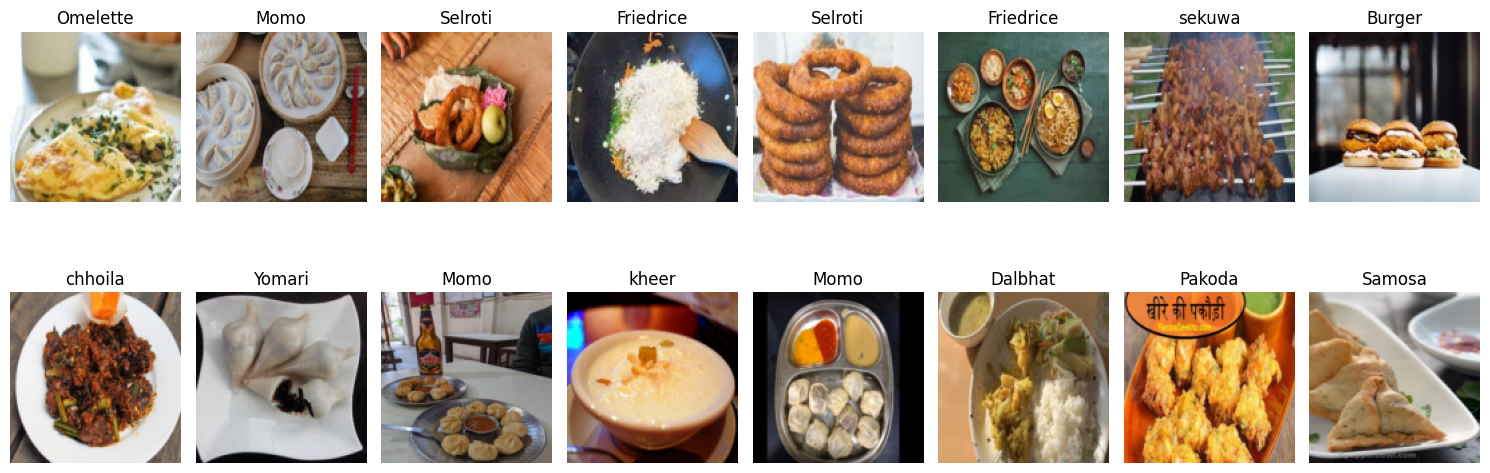

In [57]:
show_images(loader, dataset.classes)

## Image Shape Analysis
Check image sizes

In [62]:
import numpy as np

In [63]:
def image_shape_check(dataset, n=100):
    shapes = []

    for i in range(min(n, len(dataset))):
        img, _ = dataset[i]
        shapes.append(img.shape)

    print("Unique image shapes:", set(shapes))

image_shape_check(dataset)

Unique image shapes: {torch.Size([3, 128, 128])}


## Dataset Imbalance Check
Purpose:
To check whether all classes have equal number of images or not.

Why it is important:Detects bias in dataset,Prevents model from favoring majority class

Helps choose:Weighted loss,Oversampling,Data augmentation


In [68]:
def imbalance_ratio(class_counts):
    values = list(class_counts.values())
    ratio = max(values) / min(values)

    print("\n Imbalance Ratio:", round(ratio, 2))

    if ratio > 2:
        print(" Highly imbalanced dataset")
    elif ratio > 1.5:
        print(" Moderate imbalance")
    else:
        print(" Balanced dataset")

imbalance_ratio(class_counts)


 Imbalance Ratio: 13.15
 Highly imbalanced dataset
